# Load a weighted network repository dataset

In [42]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd 
import networkx as nx
import csv
import numpy as np

In [8]:
G = nx.read_edgelist(
    "soc-advogato.edges",
    create_using=nx.DiGraph(),
    comments="%",
    data=[("weight", float)]
)

In [9]:
order = G.order()
size = G.size()

print(f'Number of nodes: {order}, Number of edges: {size}')
print(list(G.edges(data=True))[0])

Number of nodes: 6551, Number of edges: 51317
('1', '1', {'weight': 0.8})


In [10]:
# Remove self loops
G.remove_edges_from(nx.selfloop_edges(G))
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Nodes: 6551, Edges: 47322


In [ ]:
# Export in GraphML
nx.write_graphml(G, "soc-advogato.graphml")

G.nodes(), G.edges()

(NodeView(('1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157'

In [23]:
degree_dict = dict(G.in_degree())
degree_dict['1']

14

In [24]:
#Access to ancillary data
for src,dst, attr_dict in G.edges(data=True):
    print(f'{src},{dst},{attr_dict}')
    break

1,2,{'weight': 1.0}


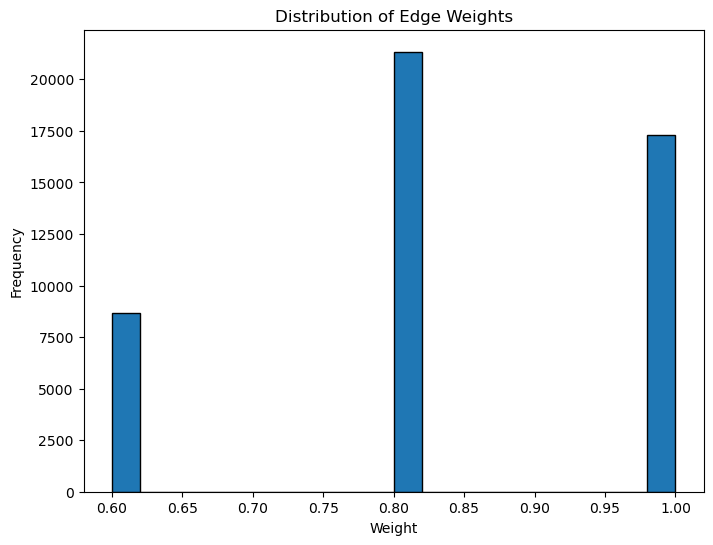

In [28]:
# plot the distribution weights
import matplotlib.pyplot as plt

# Extract edge weights from the DiGraph
weights = [data['weight'] for u, v, data in G.edges(data=True)]

# Plot the distribution of edge weights
plt.figure(figsize=(8, 6))
plt.hist(weights, bins=20, edgecolor='black')
plt.title('Distribution of Edge Weights')
plt.xlabel('Weight')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [34]:
# save
nx.write_graphml(G,path="soc-advogato.graphml") #graphml format useful for network viz 

In [ ]:
with open("advogato_edges.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Source", "Target", "Weight"])

    for u, v, data in G.edges(data=True):
        writer.writerow([u, v, data.get("weight", 1)])

# Visualization

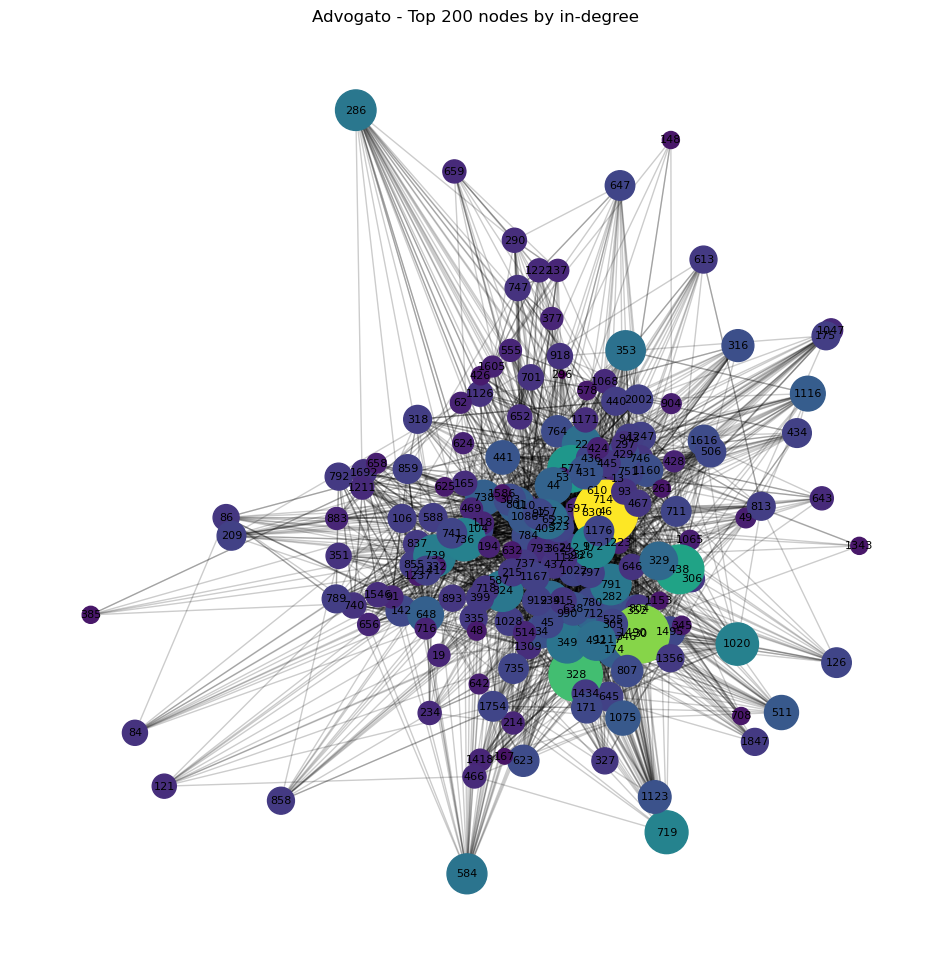

In [50]:
largest_wcc = max(nx.weakly_connected_components(G), key=len)
H = G.subgraph(largest_wcc).copy()

in_deg = dict(H.in_degree())
top_nodes = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:200]
top_node_ids = [n for n, d in top_nodes]

K = H.subgraph(top_node_ids).copy()
pos = nx.spring_layout(K, seed=42, k=0.4)

sizes = [K.in_degree(n) * 25 for n in K.nodes()]
colors = [K.in_degree(n) for n in K.nodes()]

plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(K, pos, node_size=sizes, node_color=colors, cmap=plt.cm.viridis)
nx.draw_networkx_edges(K, pos, alpha=0.2, arrows=False)
nx.draw_networkx_labels(K, pos, font_size=8)
plt.title("Advogato - Top 200 nodes by in-degree")
plt.axis("off")
plt.show()